<a href="https://colab.research.google.com/github/harshajangle/CSL701_CE12_Machine_Learning-Lab/blob/main/ML_Exp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harsha Tukaram Jangle,CE-12,CE-1

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [ ]:
# ============================================
# TASK 1: ENVIRONMENT SETUP AND DATASET
# ============================================

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# ------------------------------------------------
# Upload dataset
# ------------------------------------------------

uploaded = files.upload()

# Check uploaded file name
print("Uploaded file:", list(uploaded.keys())[0])

# ------------------------------------------------
# Load dataset
# ------------------------------------------------

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

# Column names
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# If the file does not contain column names
if df.shape[1] == 9:
    df.columns = columns

# ------------------------------------------------
# Display first 5 records
# ------------------------------------------------

print("\nFirst five records:")
display(df.head())

# ------------------------------------------------
# Dataset shape
# ------------------------------------------------

print("\nDataset Shape:")
print(df.shape)

# ------------------------------------------------
# Data types
# ------------------------------------------------

print("\nData Types:")
print(df.dtypes)

# ------------------------------------------------
# Descriptive statistics
# ------------------------------------------------

print("\nDescriptive Statistics:")
display(df.describe())

Saving archive (4).zip to archive (4) (1).zip
Uploaded file: archive (4) (1).zip

First five records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Dataset Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Counts:
Non-Diabetic (0): 500
Diabetic (1): 268

Class Percentages:
Non-Diabetic (0): 65.1 %
Diabetic (1): 34.9 %


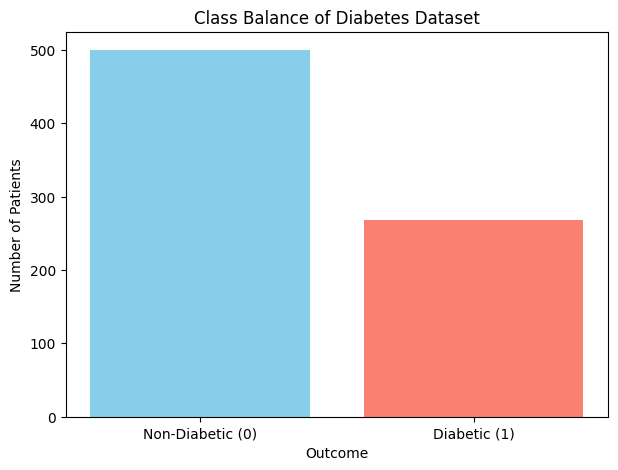

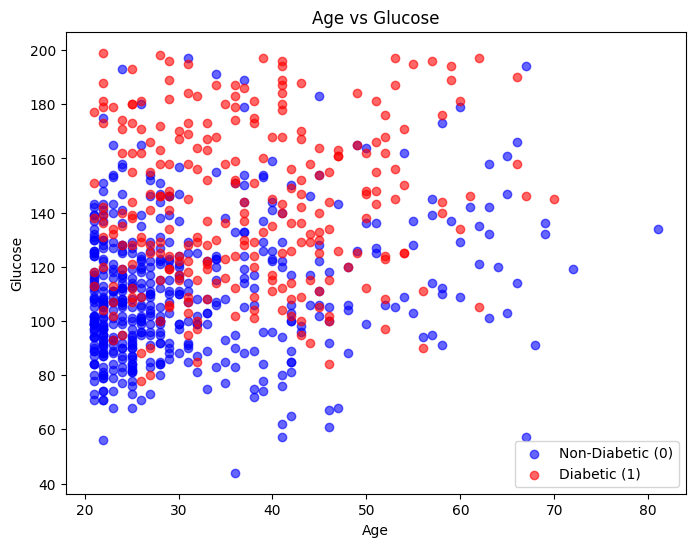

In [ ]:
# ============================================
# TASK 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# 1. Count of diabetic and non-diabetic cases

class_counts = df["Outcome"].value_counts().sort_index()

print("Class Counts:")
print("Non-Diabetic (0):", class_counts[0])
print("Diabetic (1):", class_counts[1])


# 2. Percentage of diabetic and non-diabetic cases

class_percentages = df["Outcome"].value_counts(
    normalize=True
).sort_index() * 100

print("\nClass Percentages:")
print("Non-Diabetic (0):", round(class_percentages[0], 2), "%")
print("Diabetic (1):", round(class_percentages[1], 2), "%")


# 3. Bar Chart - Class Balance

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Diabetic (0)", "Diabetic (1)"],
    [class_counts[0], class_counts[1]],
    color=["skyblue", "salmon"]
)

plt.title("Class Balance of Diabetes Dataset")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()


# 4. Scatter Plot - Age vs Glucose

plt.figure(figsize=(8, 6))

plt.scatter(
    df[df["Outcome"] == 0]["Age"],
    df[df["Outcome"] == 0]["Glucose"],
    color="blue",
    label="Non-Diabetic (0)",
    alpha=0.6
)

plt.scatter(
    df[df["Outcome"] == 1]["Age"],
    df[df["Outcome"] == 1]["Glucose"],
    color="red",
    label="Diabetic (1)",
    alpha=0.6
)

plt.title("Age vs Glucose")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.legend()

plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [ ]:
# ============================================
# TASK 3: PREPROCESSING AND HANDLING MISSING VALUES
# ============================================

# Features where 0 is physically impossible
invalid_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# ------------------------------------------------
# Check number of zero values
# ------------------------------------------------

print("Zero values before replacement:\n")

for column in invalid_features:
    print(column, ":", (df[column] == 0).sum())


# ------------------------------------------------
# Replace invalid 0 values with NaN
# ------------------------------------------------

df[invalid_features] = df[invalid_features].replace(0, np.nan)

print("\nMissing values after replacing 0 with NaN:")
print(df.isnull().sum())


# ------------------------------------------------
# Fill missing values using median
# ------------------------------------------------

for column in invalid_features:
    df[column] = df[column].fillna(df[column].median())


# ------------------------------------------------
# Check missing values after imputation
# ------------------------------------------------

print("\nMissing values after median imputation:")
print(df.isnull().sum())


# Check first 5 records
print("\nDataset after preprocessing:")
display(df.head())


Zero values before replacement:

Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0

Missing values after replacing 0 with NaN:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset after preprocessing:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [ ]:
# Task 4: Stratified Train-Test Splitting
from sklearn.model_selection import train_test_split

# Separate features (first 8 columns) and target (9th column)
X = df.iloc[:, :8]
y = df.iloc[:, 8]

# Display shapes
print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)

# Split data into 80% training and 20% testing
# stratify=y preserves the class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    train_size=0.80,
    stratify=y,
    random_state=42
)

# Display the resulting shapes
print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# Check class proportions
print("\nOriginal class distribution:")
print(y.value_counts(normalize=True) * 100)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Feature matrix X shape: (768, 8)
Target vector y shape: (768,)

Training data:
X_train: (614, 8)
y_train: (614,)

Testing data:
X_test: (154, 8)
y_test: (154,)

Original class distribution:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Training class distribution:
Outcome
0    65.14658
1    34.85342
Name: proportion, dtype: float64

Testing class distribution:
Outcome
0    64.935065
1    35.064935
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [ ]:
# Task 5: Custom Bootstrap Sampling Function

def get_bootstrap_sample(X, y):
    """
    Generate a bootstrap sample using sampling with replacement.

    Parameters:
        X : Feature matrix
        y : Target vector

    Returns:
        X_bootstrap : Resampled feature matrix
        y_bootstrap : Resampled target vector
        indices     : Selected row indices
    """

    # Number of training samples
    N = len(X)

    # Randomly select N indices with replacement
    indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[indices]
    y_bootstrap = y.iloc[indices]

    return X_bootstrap, y_bootstrap, indices




# Generate one bootstrap sample
X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

# Display sizes
print("Original training set size:", len(X_train))
print("Bootstrap X size:", len(X_bootstrap))
print("Bootstrap y size:", len(y_bootstrap))

print("\nBootstrap sample shape:")
print("X_bootstrap:", X_bootstrap.shape)
print("y_bootstrap:", y_bootstrap.shape)

# Find unique indices and their frequencies
unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

# Indices that appear more than once
duplicated_indices = unique_indices[counts > 1]

print("Number of unique samples:", len(unique_indices))
print("Number of duplicated indices:", len(duplicated_indices))

print("\nSome duplicated indices:")
print(duplicated_indices[:10])


# All possible indices in the training set
all_indices = set(range(len(X_train)))

# Indices selected in the bootstrap sample
selected_indices = set(bootstrap_indices)

# OOB indices = indices that were not selected
oob_indices = sorted(
    all_indices - selected_indices
)

print("Number of OOB samples:", len(oob_indices))

print("\nSome OOB indices:")
print(oob_indices[:10])



Original training set size: 614
Bootstrap X size: 614
Bootstrap y size: 614

Bootstrap sample shape:
X_bootstrap: (614, 8)
y_bootstrap: (614,)
Number of unique samples: 385
Number of duplicated indices: 171

Some duplicated indices:
[ 1  3  5 13 15 17 18 20 23 26]
Number of OOB samples: 229

Some OOB indices:
[2, 4, 6, 9, 11, 12, 21, 22, 24, 28]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [ ]:
# Task 6: Growing the Ensemble of Base Classifiers
from sklearn.tree import DecisionTreeClassifier

# Number of trees in the ensemble
B = 50

# Empty list to store trained decision trees
ensemble = []

# Train B decision trees
for b in range(B):

    # Generate a bootstrap sample
    X_bootstrap, y_bootstrap, indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create a fully grown Decision Tree
    tree = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )

    # Train the tree on the bootstrap sample
    tree.fit(X_bootstrap, y_bootstrap)

    # Add the trained tree to the ensemble
    ensemble.append(tree)

# Verify the number of trained models
print("Number of trees in the ensemble:", len(ensemble))

Number of trees in the ensemble: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [ ]:
# Task 7: Custom Bagging Prediction using Majority Voting

def custom_bagging_predict(ensemble, X_test):
    """
    Generate final predictions using majority voting
    from all decision trees in the ensemble.
    """

    # Store predictions from every tree
    all_predictions = []

    for model in ensemble:
        predictions = model.predict(X_test)
        all_predictions.append(predictions)

    # Convert list to NumPy array
    # Shape: (number_of_trees, number_of_test_samples)
    all_predictions = np.array(all_predictions)

    # Store final majority-voted predictions
    final_predictions = []

    # Go through each test sample
    for i in range(X_test.shape[0]):

        # Get votes from all trees for this sample
        votes = all_predictions[:, i]

        # Count votes for class 0 and class 1
        votes_class_0 = np.sum(votes == 0)
        votes_class_1 = np.sum(votes == 1)

        # Select the class with the majority votes
        if votes_class_1 > votes_class_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


In [ ]:
# Generate final predictions using custom Bagging

y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

print("Bagging Predictions:")
print(y_pred_bagging)

print("\nNumber of test samples:", len(y_pred_bagging))

print("\nUnique predicted classes:")
print(np.unique(y_pred_bagging))


Bagging Predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 1 1 0
 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0
 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1
 0 0 0 0 1 0]

Number of test samples: 154

Unique predicted classes:
[0 1]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

Confusion Matrix - Single Decision Tree:
[[87 13]
 [16 38]]

Confusion Matrix - Custom Bagging:
[[91  9]
 [10 44]]

       PERFORMANCE COMPARISON

Single Decision Tree:
Accuracy  : 0.8117
Precision : 0.7451
Recall    : 0.7037
F1-Score  : 0.7238

Custom Bagging:
Accuracy  : 0.8766
Precision : 0.8302
Recall    : 0.8148
F1-Score  : 0.8224


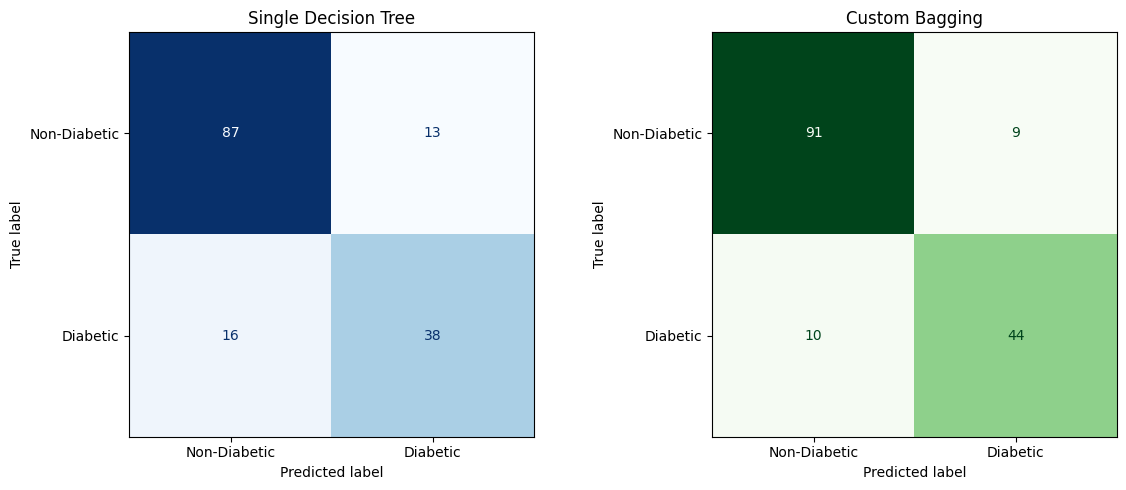

In [ ]:
# Task 8: Single Classifier vs Bagging Performance Comparison

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. Train a single fully-grown Decision Tree
# ------------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(X_train, y_train)

# Predict using single Decision Tree
y_pred_tree = single_tree.predict(X_test)


# ------------------------------------------------
# 2. Predict using Custom Bagging Classifier
# ------------------------------------------------

y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# ------------------------------------------------
# 3. Confusion Matrices
# ------------------------------------------------

cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_bagging = confusion_matrix(y_test, y_pred_bagging)

print("Confusion Matrix - Single Decision Tree:")
print(cm_tree)

print("\nConfusion Matrix - Custom Bagging:")
print(cm_bagging)


# ------------------------------------------------
# 4. Calculate Performance Metrics
# ------------------------------------------------

# Single Decision Tree
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree, zero_division=0)
tree_recall = recall_score(y_test, y_pred_tree, zero_division=0)
tree_f1 = f1_score(y_test, y_pred_tree, zero_division=0)

# Custom Bagging
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
bagging_precision = precision_score(y_test, y_pred_bagging, zero_division=0)
bagging_recall = recall_score(y_test, y_pred_bagging, zero_division=0)
bagging_f1 = f1_score(y_test, y_pred_bagging, zero_division=0)


# ------------------------------------------------
# 5. Print Results
# ------------------------------------------------

print("\n==============================================")
print("       PERFORMANCE COMPARISON")
print("==============================================")

print("\nSingle Decision Tree:")
print(f"Accuracy  : {tree_accuracy:.4f}")
print(f"Precision : {tree_precision:.4f}")
print(f"Recall    : {tree_recall:.4f}")
print(f"F1-Score  : {tree_f1:.4f}")

print("\nCustom Bagging:")
print(f"Accuracy  : {bagging_accuracy:.4f}")
print(f"Precision : {bagging_precision:.4f}")
print(f"Recall    : {bagging_recall:.4f}")
print(f"F1-Score  : {bagging_f1:.4f}")


# ------------------------------------------------
# 6. Display Confusion Matrices Graphically
# ------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Single Decision Tree
ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Non-Diabetic", "Diabetic"]
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)

axes[0].set_title("Single Decision Tree")


# Custom Bagging
ConfusionMatrixDisplay(
    confusion_matrix=cm_bagging,
    display_labels=["Non-Diabetic", "Diabetic"]
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False
)

axes[1].set_title("Custom Bagging")

plt.tight_layout()
plt.show()


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

ROC-AUC Results
-----------------------------
Single Decision Tree AUC : 0.7869
Custom Bagging AUC       : 0.9545

AUC Improvement          : 0.1677


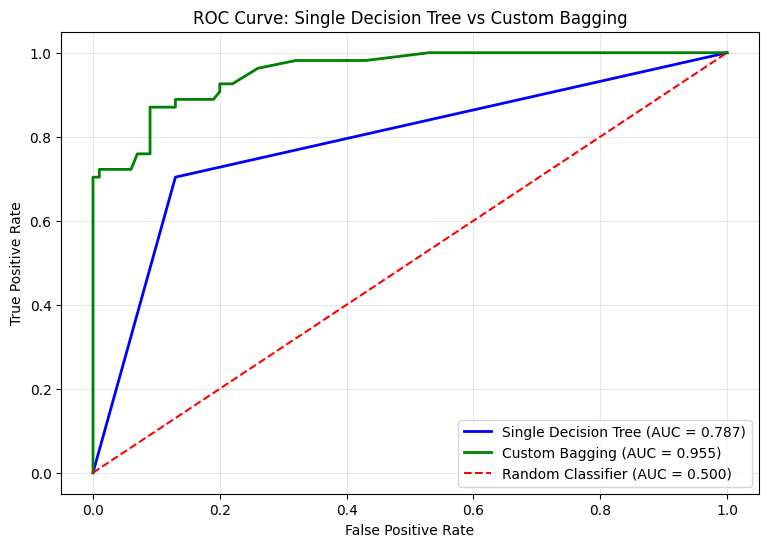

In [ ]:

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------
# 1. Probability predictions from Single Tree
# ------------------------------------------------

# Probability of class 1 (Diabetic)
y_prob_tree = single_tree.predict_proba(X_test)[:, 1]


# ------------------------------------------------
# 2. Probability predictions from Custom Bagging
# ------------------------------------------------

# Get probability of class 1 from every tree
all_tree_probabilities = []

for model in ensemble:
    probabilities = model.predict_proba(X_test)[:, 1]
    all_tree_probabilities.append(probabilities)

# Convert to NumPy array
all_tree_probabilities = np.array(all_tree_probabilities)

# Average probabilities from all 50 trees
y_prob_bagging = np.mean(
    all_tree_probabilities,
    axis=0
)


# ------------------------------------------------
# 3. Calculate ROC curves
# ------------------------------------------------

fpr_tree, tpr_tree, thresholds_tree = roc_curve(
    y_test,
    y_prob_tree
)

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    y_prob_bagging
)


# ------------------------------------------------
# 4. Calculate AUC
# ------------------------------------------------

auc_tree = roc_auc_score(
    y_test,
    y_prob_tree
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)

print("ROC-AUC Results")
print("-----------------------------")
print(f"Single Decision Tree AUC : {auc_tree:.4f}")
print(f"Custom Bagging AUC       : {auc_bagging:.4f}")

print(f"\nAUC Improvement          : {auc_bagging - auc_tree:.4f}")


# ------------------------------------------------
# 5. Plot ROC Curves
# ------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_tree,
    tpr_tree,
    color="blue",
    linewidth=2,
    label=f"Single Decision Tree (AUC = {auc_tree:.3f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    color="green",
    linewidth=2,
    label=f"Custom Bagging (AUC = {auc_bagging:.3f})"
)

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    color="red",
    linestyle="--",
    label="Random Classifier (AUC = 0.500)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Single Decision Tree vs Custom Bagging")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()


#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

Scikit-Learn BaggingClassifier Accuracy: 0.8831

Scikit-Learn BaggingClassifier Confusion Matrix:
[[91  9]
 [ 9 45]]

       CUSTOM vs SCIKIT-LEARN BAGGING

Custom Bagging Accuracy     : 0.8766
Scikit-Learn Bagging Accuracy: 0.8831

Custom Bagging Confusion Matrix:
[[91  9]
 [10 44]]

Scikit-Learn Bagging Confusion Matrix:
[[91  9]
 [ 9 45]]


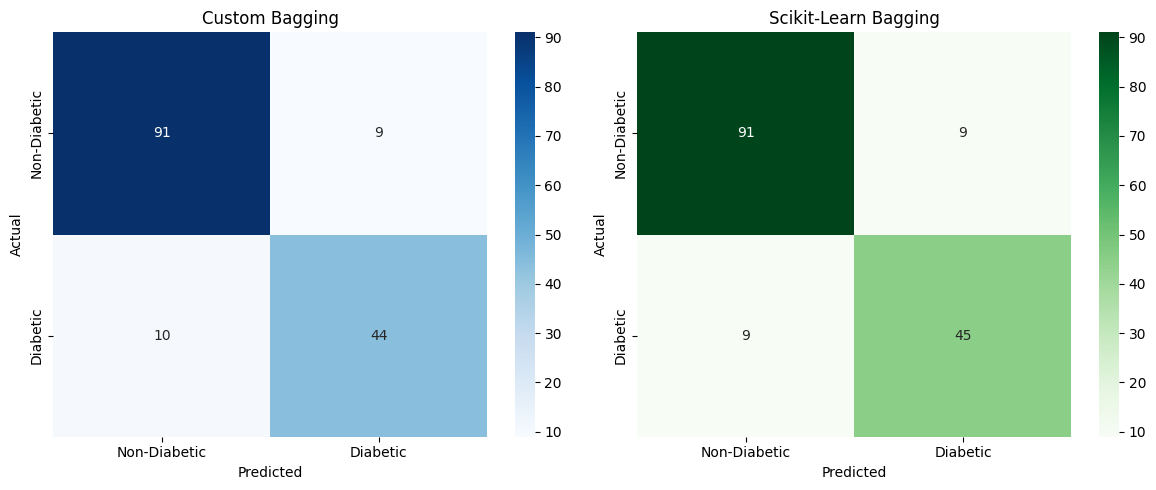

In [ ]:
# Task 10: Validation against Scikit-Learn's BaggingClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# 1. Create the base Decision Tree
# ------------------------------------------------

base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# ------------------------------------------------
# 2. Create Scikit-Learn BaggingClassifier
# ------------------------------------------------

# For newer versions of scikit-learn, use estimator=
sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    random_state=42
)

# ------------------------------------------------
# 3. Train the BaggingClassifier
# ------------------------------------------------

sklearn_bagging.fit(X_train, y_train)

# ------------------------------------------------
# 4. Predict on the test data
# ------------------------------------------------

y_pred_sklearn = sklearn_bagging.predict(X_test)

# ------------------------------------------------
# 5. Calculate accuracy
# ------------------------------------------------

sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn
)

print("Scikit-Learn BaggingClassifier Accuracy:",
      f"{sklearn_accuracy:.4f}")

# ------------------------------------------------
# 6. Calculate confusion matrix
# ------------------------------------------------

cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)

print("\nScikit-Learn BaggingClassifier Confusion Matrix:")
print(cm_sklearn)

# ------------------------------------------------
# 7. Custom Bagging accuracy
# ------------------------------------------------

custom_accuracy = accuracy_score(
    y_test,
    y_pred_bagging
)

# Custom Bagging confusion matrix
cm_custom = confusion_matrix(
    y_test,
    y_pred_bagging
)

print("\n==========================================")
print("       CUSTOM vs SCIKIT-LEARN BAGGING")
print("==========================================")

print(f"\nCustom Bagging Accuracy     : {custom_accuracy:.4f}")
print(f"Scikit-Learn Bagging Accuracy: {sklearn_accuracy:.4f}")

print("\nCustom Bagging Confusion Matrix:")
print(cm_custom)

print("\nScikit-Learn Bagging Confusion Matrix:")
print(cm_sklearn)

# ------------------------------------------------
# 8. Plot confusion matrices
# ------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Custom Bagging
sns.heatmap(
    cm_custom,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"],
    ax=axes[0]
)

axes[0].set_title("Custom Bagging")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


# Scikit-Learn Bagging
sns.heatmap(
    cm_sklearn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"],
    ax=axes[1]
)

axes[1].set_title("Scikit-Learn Bagging")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?